In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel('coffee_shop_clustering.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           5000 non-null   int64  
 1   Age                   5000 non-null   int64  
 2   Gender                5000 non-null   object 
 3   Occupation            5000 non-null   object 
 4   Monthly_Income        5000 non-null   float64
 5   Visit_Frequency       5000 non-null   int64  
 6   Avg_Spending          5000 non-null   float64
 7   Work_Activity         5000 non-null   object 
 8   Social_Activity       5000 non-null   object 
 9   Ambience_Importance   5000 non-null   object 
 10  Price_Sensitivity     5000 non-null   object 
 11  Digital_Engagement    5000 non-null   object 
 12  Purchase_Type         5000 non-null   object 
 13  Promotion_Preference  5000 non-null   object 
 14  Preferred_Time        5000 non-null   object 
dtypes: float64(2), int64(

In [3]:
mapping = {
    'Work_Activity': {
        'Very Low': 1,
        'Low': 2,
        'Medium': 3,
        'High': 4,
        'Very High': 5
    },
    'Social_Activity': {
        'Very Low': 1,
        'Low': 2,
        'Medium': 3,
        'High': 4,
        'Very High': 5
    },
    'Ambience_Importance': {
        'Very Low': 1,
        'Low': 2,
        'Medium': 3,
        'High': 4,
        'Very High': 5
    },
    'Price_Sensitivity': {
        'Very Low': 1,
        'Low': 2,
        'Medium': 3,
        'High': 4,
        'Very High': 5
    },
    'Digital_Engagement': {
        'Very Low': 1,
        'Low': 2,
        'Medium': 3,
        'High': 4,
        'Very High': 5
    },
    'Preferred_Time': {
        'Morning': 1,
        'Afternoon': 2,
        'Evening': 3
    }
}

for col, map_val in mapping.items():
    df[col] = df[col].map(map_val)

In [4]:
df = pd.get_dummies (
    df,
    columns=['Gender', 'Occupation', 'Purchase_Type', 'Promotion_Preference'],
    dtype=int
)

In [5]:
X = df.drop(columns=['Customer_ID'])

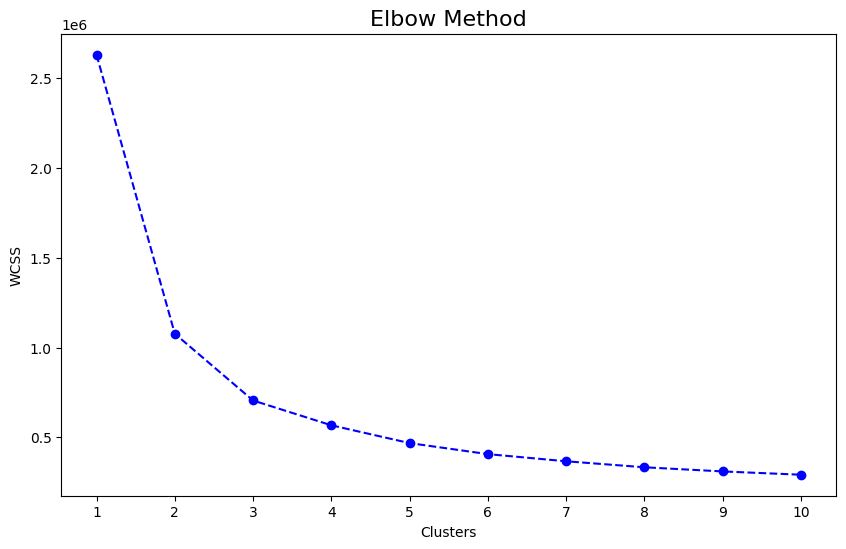

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method', fontsize=16)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

In [7]:
kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

y_kmeans = kmeans_model.fit_predict(X)

df['Cluster'] = y_kmeans
display(df.head())

,Customer_ID,Age,Monthly_Income,Visit_Frequency,Avg_Spending,Work_Activity,Social_Activity,Ambience_Importance,Price_Sensitivity,Digital_Engagement,...,Gender_Male,Occupation_Employee,Occupation_Entrepreneur,Occupation_Student,Purchase_Type_Dine-in,Purchase_Type_Takeaway,Promotion_Preference_Bundle,Promotion_Preference_Discount,Promotion_Preference_Loyalty Program,Cluster
0,1,23,1.94,7,46.55,3,5,5,5,2,...,0,1,0,0,0,1,0,1,0,2
1,2,22,1.00,4,41.02,2,5,5,5,4,...,0,0,0,1,0,1,0,1,0,2
2,3,24,3.20,6,46.18,2,5,4,4,4,...,0,0,0,1,1,0,0,1,0,2
3,4,27,3.61,4,46.51,1,5,4,5,5,...,0,0,0,1,0,1,0,1,0,2
4,5,21,3.26,8,39.21,4,5,4,5,4,...,1,1,0,0,0,1,0,1,0,2


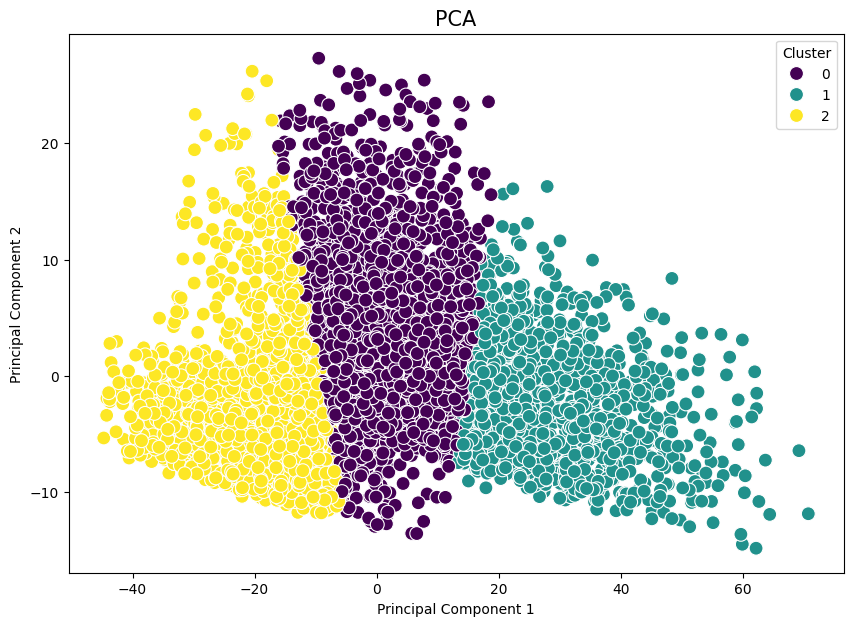

In [8]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=100)
plt.title('PCA', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [9]:
cols = [col for col in df.columns if col not in ['Customer_ID', 'Cluster']]

agg_dict = {}

for col in cols:
        agg_dict[col] = 'mean'

analytics = df.groupby('Cluster').agg(agg_dict).reset_index()

numeric_cols = analytics.select_dtypes(include='number').columns
analytics[numeric_cols] = analytics[numeric_cols].round(2)

print(analytics)

   Cluster    Age  Monthly_Income  Visit_Frequency  Avg_Spending  \
0        0  34.24            8.09             5.30         63.89   
1        1  32.13            9.98            11.26         91.59   
2        2  24.19            3.95             5.48         43.58   

   Work_Activity  Social_Activity  Ambience_Importance  Price_Sensitivity  \
0           2.69             2.33                 3.47               2.97   
1           4.52             2.11                 4.69               2.13   
2           2.06             4.19                 3.79               4.40   

   Digital_Engagement  ...  Gender_Female  Gender_Male  Occupation_Employee  \
0                2.86  ...           0.51         0.49                 0.59   
1                4.66  ...           0.49         0.51                 0.70   
2                3.62  ...           0.58         0.42                 0.35   

   Occupation_Entrepreneur  Occupation_Student  Purchase_Type_Dine-in  \
0                     0.33  

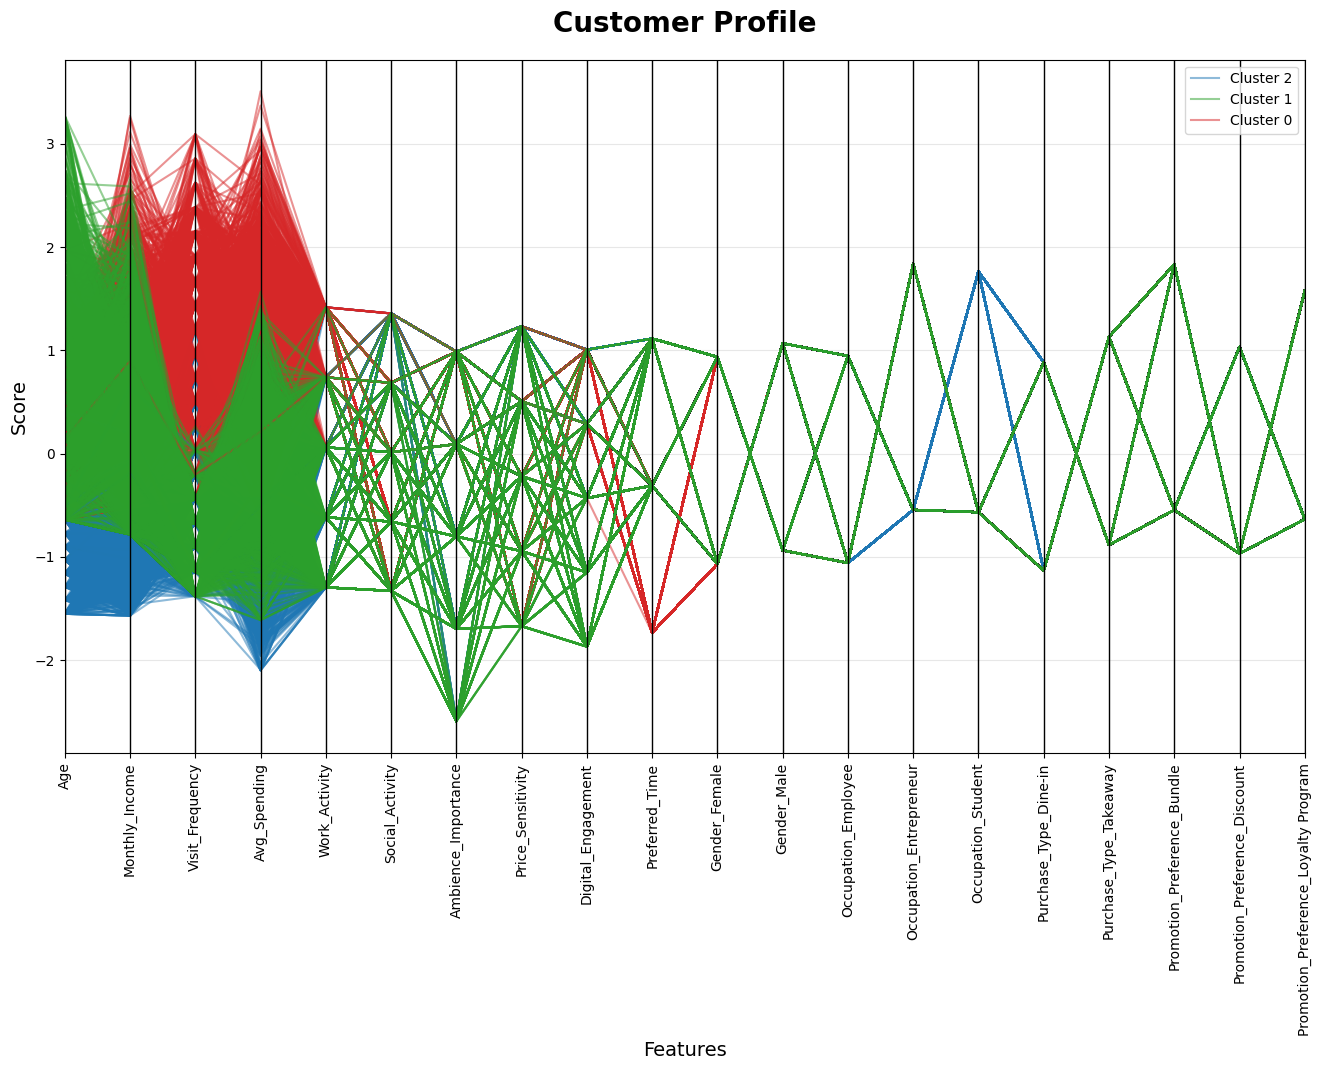

In [10]:
features = [col for col in df.columns if col not in 'Customer_ID']
X_multidim = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multidim)

kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_vis_scaled = pd.DataFrame(X_scaled, columns=features)
df_vis_scaled['Cluster'] = clusters
df_vis_scaled['Cluster'] = df_vis_scaled['Cluster'].apply(lambda x: f'Cluster {x}')

plt.figure(figsize=(16, 9))

parallel_coordinates(df_vis_scaled, 'Cluster', 
                     color=('#1F77B4', '#2CA02C', '#D62728'), 
                     linewidth=1.5, alpha=0.5)

plt.title('Customer Profile', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.show()

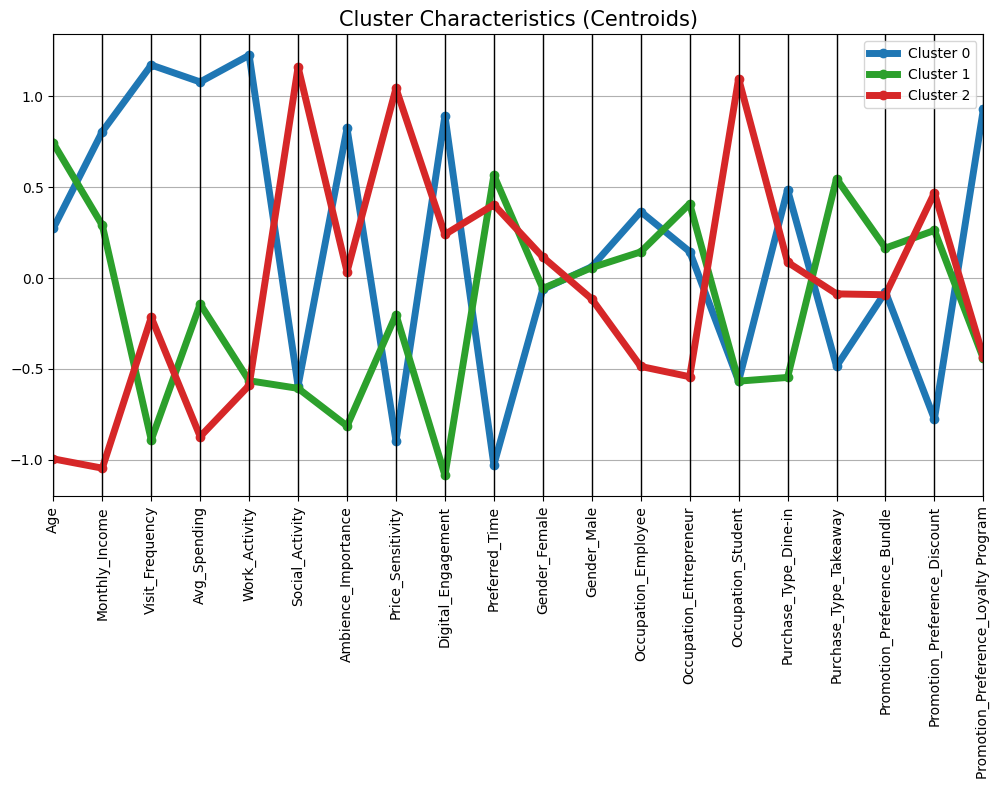

In [78]:
df_centroids = df_vis_scaled.groupby('Cluster').mean().reset_index()

plt.figure(figsize=(12, 6))
parallel_coordinates(df_centroids, 'Cluster', color=('#1F77B4', '#2CA02C', '#D62728'), linewidth=5, marker='o')

plt.title('Cluster Characteristics (Centroids)', fontsize=15)
plt.xticks(rotation=90)
plt.show()

In [11]:
analytics.to_excel('cluster_component.xlsx')

In [12]:
df.to_excel('culster.xlsx')